# Set Up

In [1]:
import mlflow
import os
import pandas as pd
import json

In [2]:
import sys
sys.path.append("../src")

from train_and_tune import (
    LinearRegressionTrainer,
    XGBTrainer,
    RandomForestTrainer,
    time_sorted_split
)
from pipeline import build_dataset


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
mlflow.set_tracking_uri("sqlite:///C:/Dev/taxi-fare-predictor/mlflow.db")
mlflow.set_experiment("taxi-fare-prediction-v2")

<Experiment: artifact_location='file:c:/Dev/taxi-fare-predictor/notebooks/mlruns/2', creation_time=1787825749992, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1787825749992, lifecycle_stage='active', name='taxi-fare-prediction-v2', tags={}, trace_location=None, workspace='default'>

In [5]:
# index to sort trip time/dates on
TIME_SORT_INDEX = 'tpep_pickup_datetime'

In [6]:
# proportion of data used for testing
TEST_PROPORTION = 0.2

In [7]:
# Features
TARGET = 'fare_amount'
NUMERICAL_FEATURES = ['trip_duration', 'passenger_count', 'trip_distance']
CATEGORICAL_FEATURES = ['pickup_borough', 'dropoff_borough', 'rate_category', 'pickup_hour', 'pickup_dayofweek']

In [8]:
df = build_dataset()

X_train, y_train, X_test, y_test = time_sorted_split(
    df,
    num_features=NUMERICAL_FEATURES,
    cat_features=CATEGORICAL_FEATURES,
    target=TARGET,
    sort_index=TIME_SORT_INDEX,
    test_proportion=TEST_PROPORTION
)

## Linear Regression Initial Fit

In [9]:
trainer = LinearRegressionTrainer()

with mlflow.start_run(run_name="LinearRegression"):
    trainer.train(X_train, y_train)
    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(params={})
    trainer.print_results()


Train RMSE: 4.150 | Test RMSE: 4.874 | Gap: 0.725
Train R2: 0.938 | Test R2: 0.914


## XGBoost Initial Fit

In [10]:
XG_N_ESTIMATORS = 300
XG_LEARNING_RATE = 0.05
XG_MAX_DEPTH = 6
XG_SUBSAMPLE = 0.8
XG_COLSAMPLE_BYTREE = 0.8

In [11]:
trainer = XGBTrainer(
    n_estimators=XG_N_ESTIMATORS,
    learning_rate=XG_LEARNING_RATE,
    max_depth=XG_MAX_DEPTH,
    subsample=XG_SUBSAMPLE,
    colsample_bytree=XG_COLSAMPLE_BYTREE
)

with mlflow.start_run(run_name="XGBoost"):
    trainer.train(X_train, y_train)
    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(params={
        "n_estimators": XG_N_ESTIMATORS,
        "learning_rate": XG_LEARNING_RATE,
        "max_depth": XG_MAX_DEPTH,
        "subsample": XG_SUBSAMPLE,
        "colsample_bytree": XG_COLSAMPLE_BYTREE
    })
    trainer.print_results()


Train RMSE: 1.923 | Test RMSE: 2.232 | Gap: 0.309
Train R2: 0.987 | Test R2: 0.982


## Random Forest Initial Fit

In [12]:
RF_N_ESTIMATORS = 200
RF_MAX_DEPTH = 6
RF_MIN_SAMPLES_LEAF = 1
RF_MAX_FEATURES = 'sqrt'

In [13]:
trainer = RandomForestTrainer(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    max_features=RF_MAX_FEATURES
)

with mlflow.start_run(run_name="RandomForest"):
    trainer.train(X_train, y_train)
    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(params={
        "n_estimators": RF_N_ESTIMATORS,
        "max_depth": RF_MAX_DEPTH,
        "min_samples_leaf": RF_MIN_SAMPLES_LEAF,
        "max_features": RF_MAX_FEATURES
    })
    trainer.print_results()


Train RMSE: 5.052 | Test RMSE: 5.811 | Gap: 0.759
Train R2: 0.908 | Test R2: 0.877


## Initial Comparison

The following table summaries the inital metrics of the three models after a first fit. We have the root mean squared error (RMSE), mean average error (MAE) and the R2 score for both the test and train run. 

In [14]:
experiment_name = "taxi-fare-prediction-v2"
experiment = mlflow.get_experiment_by_name(experiment_name)

df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
df = df.head(3)

metrics_df = df[[
    "run_id",
    "params.model_type",
    "metrics.train_rmse",
    "metrics.test_rmse",
    "metrics.train_mae",
    "metrics.test_mae",
    "metrics.train_r2",
    "metrics.test_r2",
    "metrics.rmse_gap"
]]

metrics_df.sort_values("metrics.test_rmse")



,run_id,params.model_type,metrics.train_rmse,metrics.test_rmse,metrics.train_mae,metrics.test_mae,metrics.train_r2,metrics.test_r2,metrics.rmse_gap
1,8cddff404ee34fd2af535e3ba6eaeda8,XGBRegressor,1.922602,2.231602,0.687619,0.805642,0.986670,0.981927,0.309001
2,21f9b9875b554d46b6a3cd39371a406a,LinearRegression,4.149665,4.874208,2.152139,2.730622,0.937904,0.913783,0.724543
0,b680ca00642348ec9628346ebbcb8fde,RandomForestRegressor,5.052176,5.810828,3.297821,3.670711,0.907957,0.877465,0.758652


The following graphs show the RMSE and R2 score of the training and testing runs of all the models.

Plot already exists — skipping save.


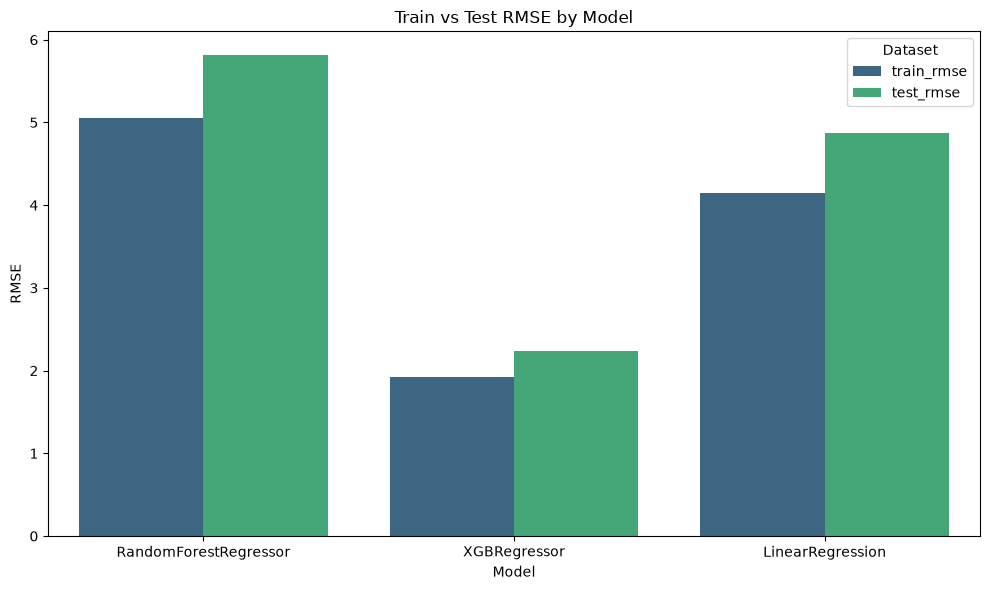

In [15]:
rmse_df = df[[
    "params.model_type",
    "metrics.train_rmse",
    "metrics.test_rmse"
]].copy()
rmse_df.columns = ["model", "train_rmse", "test_rmse"]
rmse_long = rmse_df.melt(
    id_vars="model",
    value_vars=["train_rmse", "test_rmse"],
    var_name="dataset",
    value_name="rmse"
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=rmse_long,
    x="model",
    y="rmse",
    hue="dataset",
    palette="viridis"
)

plt.title("Train vs Test RMSE by Model")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.legend(title="Dataset")
plt.tight_layout()

save_path_RMSE = "../Graphs/Initial_RMSE_by_Model.png"

if not os.path.exists(save_path_RMSE):
    plt.savefig(save_path_RMSE, dpi=300, bbox_inches="tight")
    print("Saved plot.")
else:
    print("Plot already exists — skipping save.")

plt.show()



Plot already exists — skipping save.


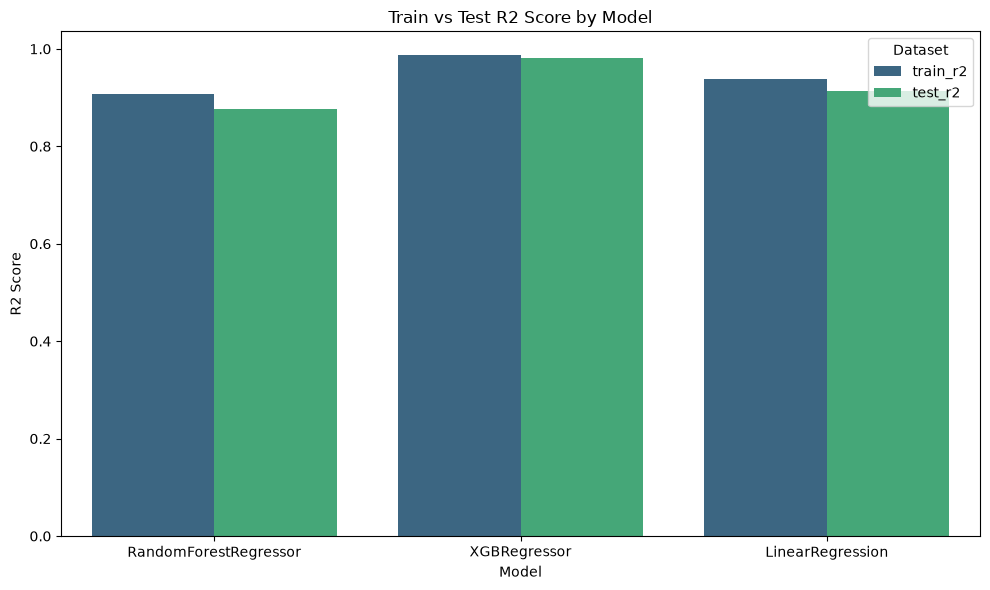

In [16]:
r2_df = df[[
    "params.model_type",
    "metrics.train_r2",
    "metrics.test_r2"
]].copy()
r2_df.columns = ["model", "train_r2", "test_r2"]
r2_long = r2_df.melt(
    id_vars="model",
    value_vars=["train_r2", "test_r2"],
    var_name="dataset",
    value_name="r2"
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=r2_long,
    x="model",
    y="r2",
    hue="dataset",
    palette="viridis"
)

plt.title("Train vs Test R2 Score by Model")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.legend(title="Dataset")
plt.tight_layout()

save_path_R2 = "../Graphs/Initial_R2_by_Model.png"

if not os.path.exists(save_path_R2):
    plt.savefig(save_path_R2, dpi=300, bbox_inches="tight")
    print("Saved plot.")
else:
    print("Plot already exists — skipping save.")

plt.show()


The XGBoost model has the lowest RMSE error and the highest R2 score which suggests it is the best intital fit to the data.

## XGBoost Hyperparameter Tuning

In [17]:
xgb_search_space = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

N_ITER = 10
CV = 3
SCORING_TYPE = 'neg_root_mean_squared_error'


In [18]:
trainer = XGBTrainer()

with mlflow.start_run(run_name="XGBoost_Tuned"):
    best_params = trainer.tune(
        X_train,
        y_train,
        param_distributions=xgb_search_space,
        n_iter=N_ITER,
        cv=CV,
        scoring=SCORING_TYPE
    )

    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(best_params)
    trainer.print_results()


Train RMSE: 1.755 | Test RMSE: 2.209 | Gap: 0.454
Train R2: 0.989 | Test R2: 0.982


## Random Forest Hyperparameter Tuning

In [19]:
rf_search_space = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt"]
}

In [20]:
trainer = RandomForestTrainer()

with mlflow.start_run(run_name="RandomForest_Tuned"):
    best_params = trainer.tune(
        X_train,
        y_train,
        param_distributions=rf_search_space,
        n_iter=N_ITER,
        scoring=SCORING_TYPE,
        cv=CV
    )

    trainer.evaluate(X_train, y_train, X_test, y_test)
    trainer.log_to_mlflow(best_params)
    trainer.print_results()

Train RMSE: 1.760 | Test RMSE: 2.819 | Gap: 1.060
Train R2: 0.989 | Test R2: 0.971


# Tuned Model Comparison

Again, we will compare the candidate models on RMSE and R2 score for both training and testing after hyperparameyer tuning. 

In [21]:
mlflow.search_runs()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.test_rmse,metrics.train_mae,metrics.test_mae,metrics.test_r2,...,params.max_features,params.model_type,params.colsample_bytree,params.subsample,params.learning_rate,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.runName,tags.stage
0,8465d6c1f9bb461aad9bc49860f7ae82,2,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-27 14:18:48.822000+00:00,2026-08-27 15:46:40.988000+00:00,2.819234,0.809499,1.182860,0.971157,...,sqrt,RandomForestRegressor,None,None,None,c_reg,model_comparison.ipynb,NOTEBOOK,RandomForest_Tuned,None
1,f6d28775722c4612bafa2044aded62b7,2,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-27 14:11:54.897000+00:00,2026-08-27 14:18:48.783000+00:00,2.209356,0.641166,0.762072,0.982286,...,None,XGBRegressor,1.0,1.0,0.05,c_reg,model_comparison.ipynb,NOTEBOOK,XGBoost_Tuned,None
2,b680ca00642348ec9628346ebbcb8fde,2,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-27 14:09:30.419000+00:00,2026-08-27 14:11:54.378000+00:00,5.810828,3.297821,3.670711,0.877465,...,sqrt,RandomForestRegressor,None,None,None,c_reg,model_comparison.ipynb,NOTEBOOK,RandomForest,None
3,8cddff404ee34fd2af535e3ba6eaeda8,2,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-27 14:08:55.908000+00:00,2026-08-27 14:09:30.385000+00:00,2.231602,0.687619,0.805642,0.981927,...,None,XGBRegressor,0.8,0.8,0.05,c_reg,model_comparison.ipynb,NOTEBOOK,XGBoost,None
4,21f9b9875b554d46b6a3cd39371a406a,2,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-27 14:08:36.795000+00:00,2026-08-27 14:08:55.879000+00:00,4.874208,2.152139,2.730622,0.913783,...,None,LinearRegression,None,None,None,c_reg,model_comparison.ipynb,NOTEBOOK,LinearRegression,None
5,717d9e28045946b6bb1e0afb8d56acb3,2,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-27 10:30:15.162000+00:00,2026-08-27 11:14:07.446000+00:00,2.753001,0.791138,1.135305,0.972496,...,sqrt,RandomForestRegressor,None,None,None,c_reg,model_comparison.ipynb,NOTEBOOK,RandomForest_Tuned,None
6,e9bd924bee09457d8b58141419c965cb,2,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-27 10:20:03.446000+00:00,2026-08-27 10:30:15.091000+00:00,2.206354,0.640052,0.760931,0.982334,...,None,XGBRegressor,1.0,1.0,0.05,c_reg,model_comparison.ipynb,NOTEBOOK,production,production
7,a80d17941b5b4dcc87c042bd23d95b86,2,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-27 10:16:58.318000+00:00,2026-08-27 10:20:00.628000+00:00,5.982864,3.380477,3.791520,0.870102,...,sqrt,RandomForestRegressor,None,None,None,c_reg,model_comparison.ipynb,NOTEBOOK,RandomForest,None
8,3e96d81a6bf9406684a310ff2d31fb80,2,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-27 10:16:24.531000+00:00,2026-08-27 10:16:58.285000+00:00,2.233215,0.688769,0.807676,0.981901,...,None,XGBRegressor,0.8,0.8,0.05,c_reg,model_comparison.ipynb,NOTEBOOK,XGBoost,None
9,83795f82860c4a22a1afdcbf5e2c0db4,2,FINISHED,file:c:/Dev/taxi-fare-predictor/notebooks/mlru...,2026-08-27 10:15:56.535000+00:00,2026-08-27 10:16:24.484000+00:00,4.874208,2.152139,2.730622,0.913783,...,None,LinearRegression,None,None,None,c_reg,model_comparison.ipynb,NOTEBOOK,LinearRegression,None


In [22]:
experiment_name = "taxi-fare-prediction-v2"
experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
xgboost_run_id = runs[runs['tags.mlflow.runName'] == 'XGBoost_Tuned'].iloc[0]['run_id']
rf_run_id = runs[runs['tags.mlflow.runName'] == 'RandomForest_Tuned'].iloc[0]['run_id']

In [23]:
from mlflow.tracking import MlflowClient
client = MlflowClient()

xgboost_run = client.get_run(xgboost_run_id)
rf_run = client.get_run(rf_run_id)

xgboost_params = xgboost_run.data.params
xgboost_metrics = xgboost_run.data.metrics
xgboost_tags = xgboost_run.data.tags

rf_params = rf_run.data.params
rf_metrics = rf_run.data.metrics
rf_tags = rf_run.data.tags

RMSE plot already exists — skipping save.


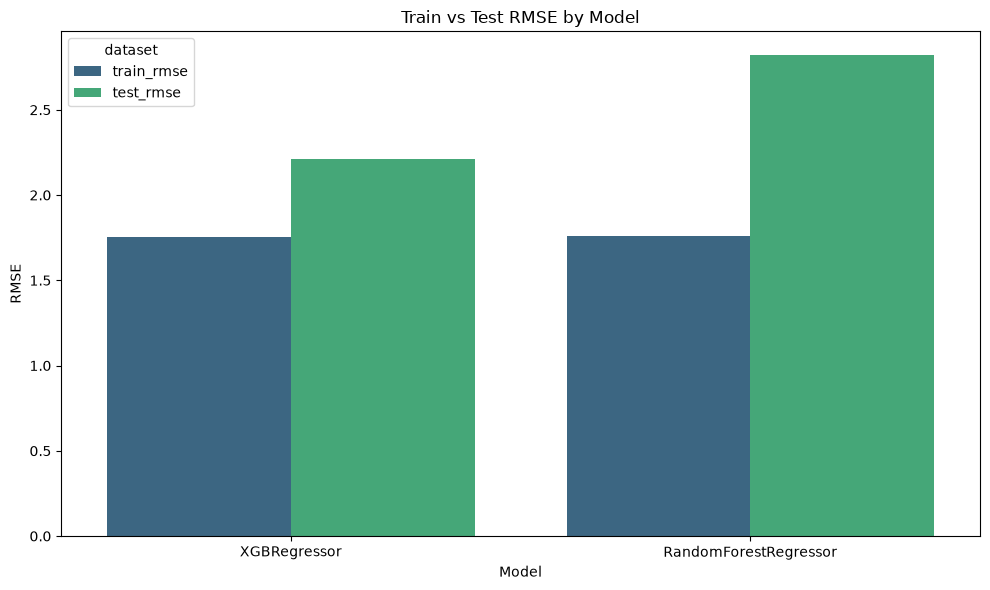

In [24]:
# Build RMSE comparison DataFrame
rmse_df = pd.DataFrame([
    {
        "model": "XGBRegressor",
        "train_rmse": xgboost_metrics["train_rmse"],
        "test_rmse": xgboost_metrics["test_rmse"]
    },
    {
        "model": "RandomForestRegressor",
        "train_rmse": rf_metrics["train_rmse"],
        "test_rmse": rf_metrics["test_rmse"]
    }
])

# Melt into long format
rmse_long = rmse_df.melt(id_vars="model", var_name="dataset", value_name="rmse")

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=rmse_long, x="model", y="rmse", hue="dataset", palette="viridis")
plt.title("Train vs Test RMSE by Model")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.tight_layout()

# Save
save_path_rmse = "../Graphs/XGB_RF_RMSE.png"
if not os.path.exists(save_path_rmse):
    plt.savefig(save_path_rmse)
else:
    print("RMSE plot already exists — skipping save.")

plt.show()


R² plot already exists — skipping save.


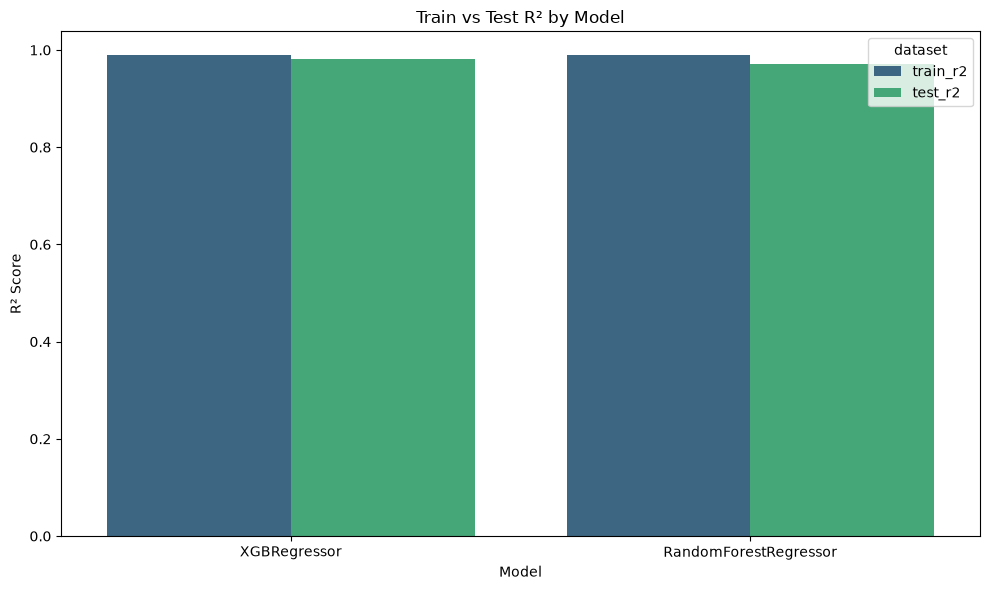

In [25]:
r2_df = pd.DataFrame([
    {
        "model": "XGBRegressor",
        "train_r2": xgboost_metrics["train_r2"],
        "test_r2": xgboost_metrics["test_r2"]
    },
    {
        "model": "RandomForestRegressor",
        "train_r2": rf_metrics["train_r2"],
        "test_r2": rf_metrics["test_r2"]
    }
])

r2_long = r2_df.melt(id_vars="model", var_name="dataset", value_name="r2")

plt.figure(figsize=(10,6))
sns.barplot(data=r2_long, x="model", y="r2", hue="dataset", palette="viridis")
plt.title("Train vs Test R² by Model")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.tight_layout()

save_path_r2 = "../Graphs/XGB_RF_R2.png"
if not os.path.exists(save_path_r2):
    plt.savefig(save_path_r2)
else:
    print("R² plot already exists — skipping save.")

plt.show()


# Chosen Model

We load our model versioning function that names our chosen model as production etc. We can then load and view the paramaters and metrics for this model.

In [26]:
training_columns = X_train.columns.tolist()

with open('../data/model_training_columns.json', 'w') as f:
    json.dump(training_columns, f)

print(f"Saved {len(training_columns)} column names")

Saved 52 column names


In [27]:
from model_versioning import promote_run_to_production

In [28]:
promote_run_to_production(xgboost_run_id, model_name="taxi-fare-xgboost")

True

These are the following parameters chosen by the the RandomisedCVSearch as the best performing combination.

In [29]:
prod_params = pd.DataFrame([xgboost_params])
prod_params

,model_type,subsample,n_estimators,max_depth,learning_rate,colsample_bytree
0,XGBRegressor,1.0,300,8,0.05,1.0


In [30]:
versions = client.search_model_versions("name='taxi-fare-xgboost'")
for v in versions:
    print(v.version, v.current_stage, v.run_id)


5 None f6d28775722c4612bafa2044aded62b7
4 None e9bd924bee09457d8b58141419c965cb
3 None 84179405d95d4596a409c097e8bfdde9
2 None da35fe17b7fe47c4ab49820a709912af
1 None d1def0aad03c4c919c926f526862aaa4


In [6]:
from mlflow.client import MlflowClient

# Register the model using the Run ID from your XGBoost run
run_id = "8cddff404ee34fd2af535e3ba6eaeda8"
model_uri = f"runs:/{run_id}/model"
mlflow.register_model(model_uri, "taxi-fare-xgboost")

# Promote to production
client = MlflowClient()
client.set_registered_model_alias(
    name="taxi-fare-xgboost",
    alias="production",
    version=1
)

Registered model 'taxi-fare-xgboost' already exists. Creating a new version of this model...
2026/08/27 17:02:23 WARNING mlflow.tracking._model_registry.fluent: Run with id 8cddff404ee34fd2af535e3ba6eaeda8 has no artifacts at artifact path 'model', registering model based on models:/m-cbb2c702f2544e8097a44ab9133e4943 instead
Created version '6' of model 'taxi-fare-xgboost'.


# Simple Prediction Test

This simple example shows that the model can predict a fare based off some input features.

In [7]:
from predict import predict_fare

In [9]:
predict_fare(trip_duration=12.0,
    passenger_count=1,
    trip_distance=2.3,
    pickup_borough='Manhattan',
    dropoff_borough='Manhattan',
    rate_category='standard',
    pickup_hour=14,
    pickup_dayofweek=2)



13.669797897338867